In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap

data = np.array([[0.03,0.19,0.34,0.46,0.78,0.81,1.08,1.18,1.39,1.60,1.65,1.90],
                 [0.67,0.85,1.05,1.00,1.40,1.50,1.30,1.54,1.55,1.68,1.73,1.60]])

def model(phi,x):
    y_pred = phi[0] + phi[1]*x
    return y_pred

In [2]:
def draw_model(data, model, phi, title=None):
    x_model = np.arange(0,2,0.01)
    y_model = model(phi, x_model)
    
    fix, ax = plt.subplots()
    ax.plot(data[0,:],data[1,:],'bo')
    ax.plot(x_model,y_model,'m-')
    ax.set_xlim([0,2]);ax.set_ylim([0,2])
    ax.set_xlabel('x'); ax.set_ylabel('y')
    ax.set_aspect('equal')
    if title is not None:
        ax.set_title(title)
    plt.show()

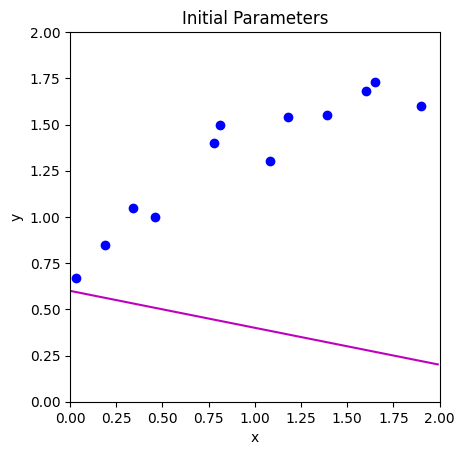

In [3]:
phi = np.zeros((2,1))
phi[0] = 0.6
phi[1] = -0.2
draw_model(data, model, phi, "Initial Parameters")

In [7]:
def compute_loss(data_x, data_y, model, phi):
    pred_y = model(phi, data_x)
    loss = np.sum((pred_y - data_y) ** 2)
    return loss

loss = compute_loss(data[0,:],data[1,:],model,np.array([[0.6],[-0.2]]))
print('Your loss = %3.3f, Correct loss = %3.3f'%(loss, 12.367))

Your loss = 12.367, Correct loss = 12.367


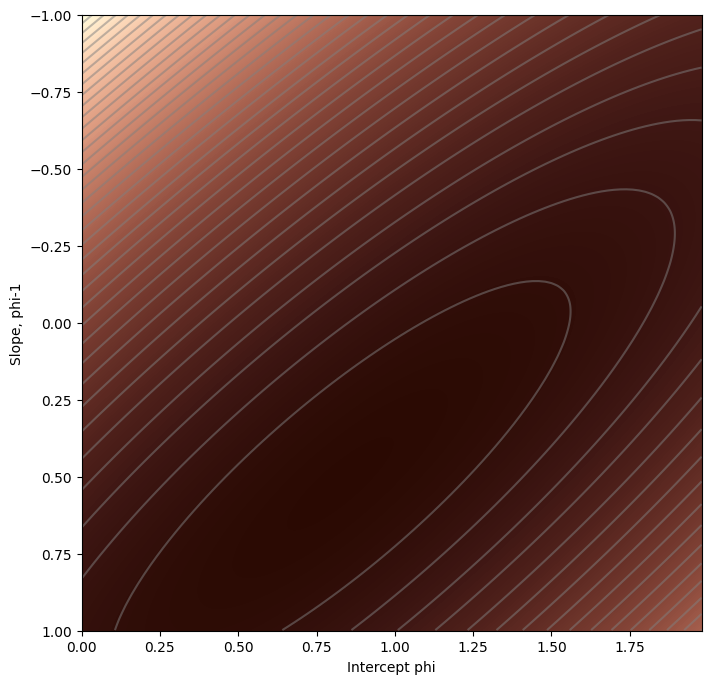

In [ ]:
def draw_loss_function(compute_loss, data,  model, phi_iters = None):
  # Define pretty colormap
  my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
  my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
  r = np.floor(my_colormap_vals_dec/(256*256))
  g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
  b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
  my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

  # Make grid of intercept/slope values to plot
  intercepts_mesh, slopes_mesh = np.meshgrid(np.arange(0.0,2.0,0.02), np.arange(-1.0,1.0,0.002))
  loss_mesh = np.zeros_like(slopes_mesh)
  # Compute loss for every set of parameters
  for idslope, slope in np.ndenumerate(slopes_mesh):
     loss_mesh[idslope] = compute_loss(data[0,:], data[1,:], model, np.array([[intercepts_mesh[idslope]], [slope]]))

  fig,ax = plt.subplots()
  fig.set_size_inches(8,8)
  ax.contourf(intercepts_mesh,slopes_mesh,loss_mesh,256,cmap=my_colormap)
  ax.contour(intercepts_mesh,slopes_mesh,loss_mesh,40,colors=['#80808080'])
  if phi_iters is not None:
    ax.plot(phi_iters[0,:], phi_iters[1,:],'go-')
  ax.set_ylim([1,-1])
  ax.set_xlabel('Intercept phi'); ax.set_ylabel('Slope, phi-1')
  plt.show()

draw_loss_function(compute_loss, data, model)

In [17]:
def compute_gradient(data_x, data_y, phi):
    delta = 1e-6
    phi_plus = phi.copy()
    phi_plus[0] = phi_plus[0] + delta
    loss_plus = compute_loss(data_x, data_y, model, phi_plus)

    phi_minus = phi.copy()
    phi_minus[0] = phi_minus[0] - delta
    loss_minus = compute_loss(data_x, data_y, model, phi_minus)

    dl_dphi0 = (loss_plus - loss_minus) / (2 * delta)
    
    phi_plus = phi.copy()
    phi_plus[1] = phi_plus[1] + delta
    loss_plus = compute_loss(data_x, data_y, model, phi_plus)

    phi_minus = phi.copy()
    phi_minus[1] = phi_minus[1] - delta
    loss_minus = compute_loss(data_x, data_y, model, phi_minus)

    dl_dphi1 = (loss_plus - loss_minus) / (2 * delta)
    return np.array([[dl_dphi0],[dl_dphi1]])

gradient = compute_gradient(data[0,:],data[1,:], phi)
print("Your gradients: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))

delta = 0.0001
dl_dphi0_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[delta],[0]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
dl_dphi1_est = (compute_loss(data[0,:],data[1,:],model,phi+np.array([[0],[delta]])) - \
                    compute_loss(data[0,:],data[1,:],model,phi))/delta
print("Approx gradients: (%3.3f,%3.3f)"%(dl_dphi0_est,dl_dphi1_est))

Your gradients: (-21.904,-26.840)
Approx gradients: (-21.903,-26.839)


/var/folders/b7/hx5w70bx70j8xxmzlz0wlzdr0000gn/T/ipykernel_60970/3686089122.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Your gradients: (%3.3f,%3.3f)"%(gradient[0],gradient[1]))


NOW WE CAN FINALLY PERFORM GRADIENT DESCENT AFTER UNDESTANDING THE BASICS

In [18]:
def loss_function_1D(dist_prop, data, model, phi_start, search_direction):
    return compute_loss(data[0,:], data[1,:], model, phi_start - search_direction * dist_prop)

def line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose = False):
    a = 0
    b = 0.33 * max_dist
    c = 0.66 * max_dist
    d = 1.0 * max_dist
    n_iter = 0

    while np.abs(b-c) > thresh and n_iter < max_iter:
        n_iter = n_iter+1
        lossa = loss_function_1D(a, data, model, phi, gradient)
        lossb = loss_function_1D(b, data, model, phi, gradient)
        lossc = loss_function_1D(c, data, model, phi, gradient)
        lossd = loss_function_1D(d, data, model, phi, gradient)

        if verbose:
            print('Iter %d, a=%3.3f, b=%3.3f, c=%3.3f, d=%3.3f'%(n_iter, a,b,c,d))
            print('a %f, b%f, c%f, d%f'%(lossa,lossb,lossc,lossd))

        if np.argmin((lossa, lossb, lossc, lossd)) == 0:
            b = a+ (b-a)/2
            c = a+ (c-a)/2
            d = a+ (d-a)/2
            continue;

        if lossb < lossc:
            d = c
            b = a+ (d-a)/3
            c = a+ 2*(d-a)/3
            continue    

        a = b
        b = a+ (d-a)/3
        c = a+ 2*(d-a)/3

    return (b + c) / 2.0

In [21]:
def gradient_descent_step(phi, data, model):
    data_x = data[0,:]
    data_y = data[1,:]

    gradient = compute_gradient(data_x, data_y, phi)

    def loss_function(alpha):
        return compute_loss(data_x, data_y, model, phi - alpha * gradient)
    
    alpha = line_search(data, model, phi, gradient, thresh=.00001, max_dist = 0.1, max_iter = 15, verbose = False)

    phi = phi - alpha * gradient

    return phi


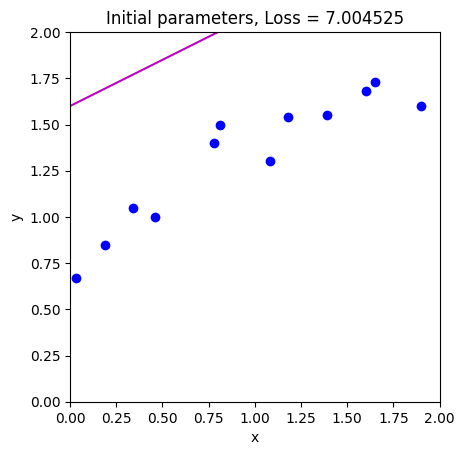

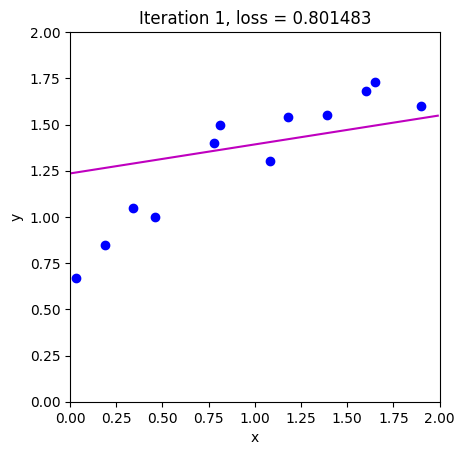

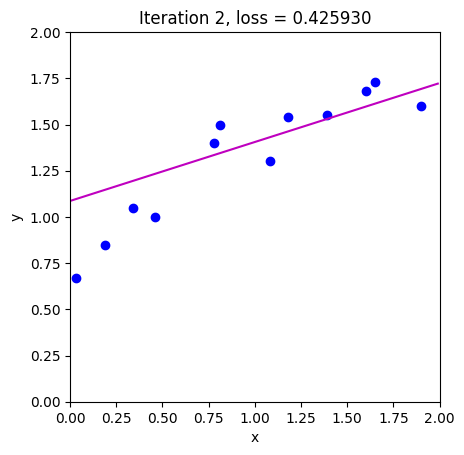

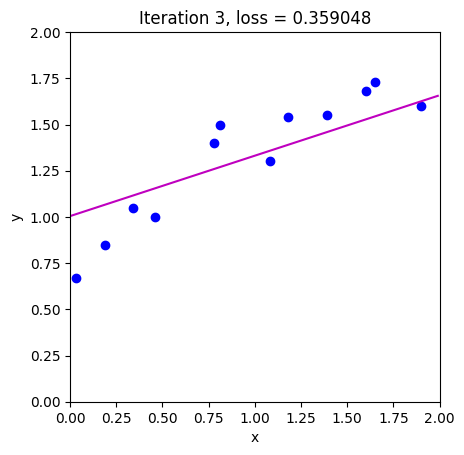

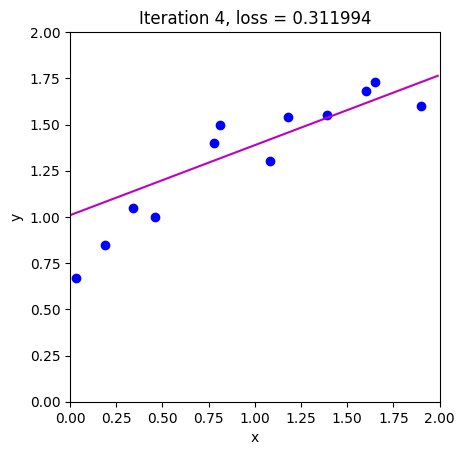

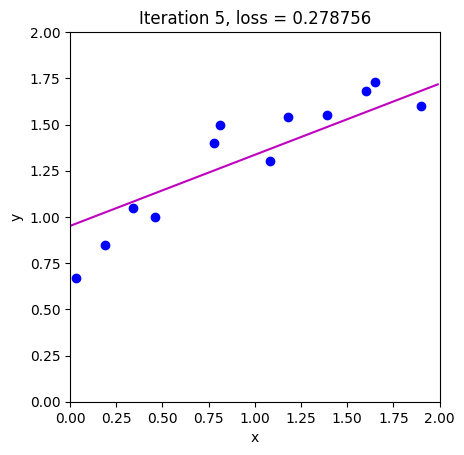

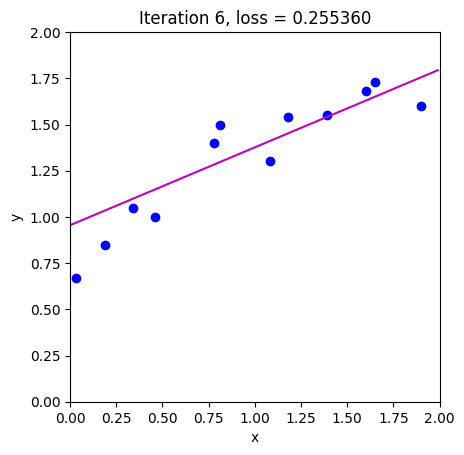

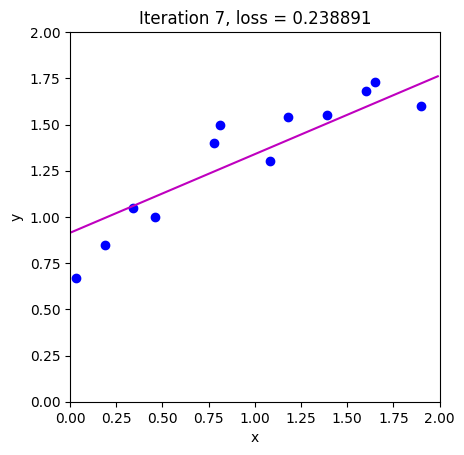

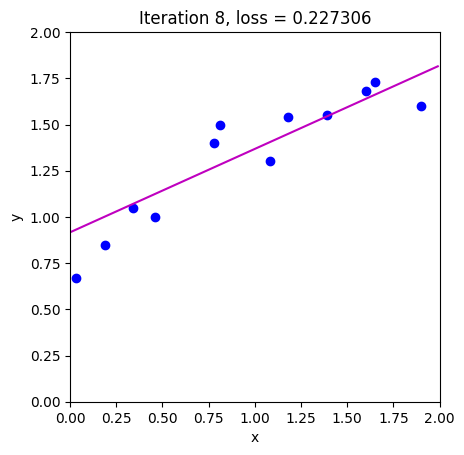

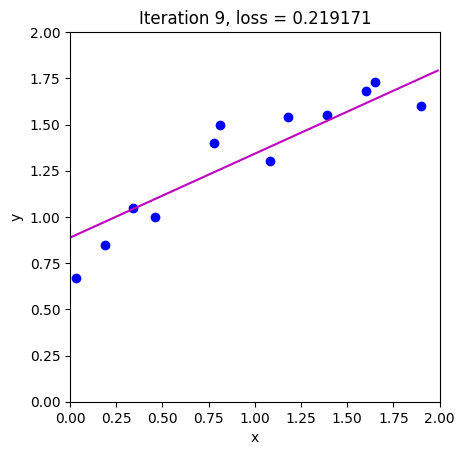

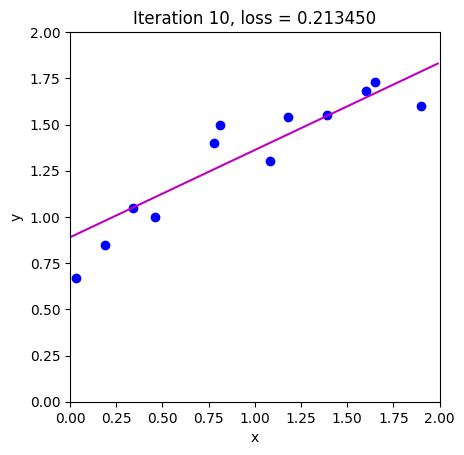

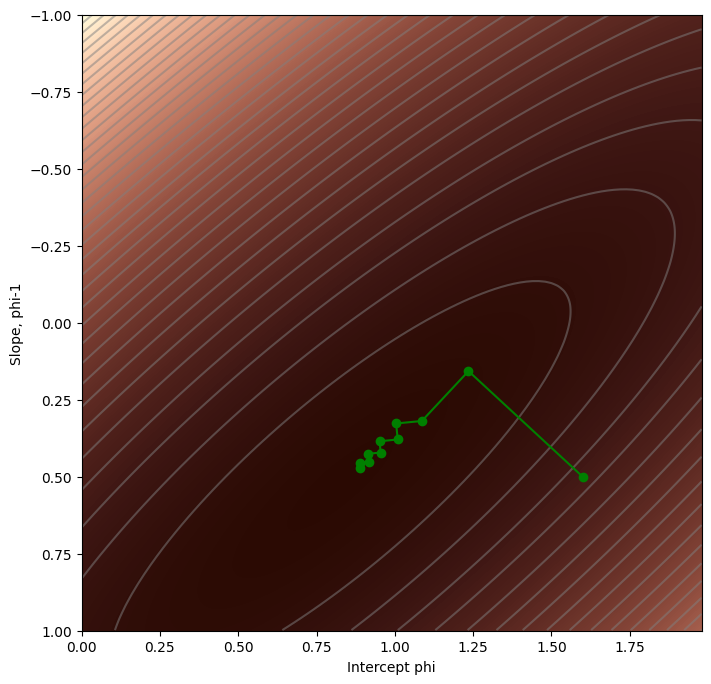

In [22]:
n_steps = 10
phi_all = np.zeros((2, n_steps+1))
phi_all[0,0] = 1.6
phi_all[1,0] = 0.5

loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,0:1])
draw_model(data,model,phi_all[:,0:1], "Initial parameters, Loss = %f"%(loss))

for c_step in range (n_steps):
  phi_all[:,c_step+1:c_step+2] = gradient_descent_step(phi_all[:,c_step:c_step+1],data, model)
  loss =  compute_loss(data[0,:], data[1,:], model, phi_all[:,c_step+1:c_step+2])
  draw_model(data,model,phi_all[:,c_step+1], "Iteration %d, loss = %f"%(c_step+1,loss))

draw_loss_function(compute_loss, data, model,phi_all)